# Solar Farms Defect Inspection

# Configuration

In [3]:
from pathlib import Path
from datetime import datetime

# Project
PROJECT_ROOT = Path("/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection")

# Inputs

RGB_IMAGE = Path(
    "/home/hraj/Workspace/Solor_defect_DB/solar-panel-segmentation/"
    "yolo_dataset/test/images/"
    "DJI_0173_JPG.rf.113aabf9201cc01fb8777ada36c407cd.jpg"
)
    # "/home/hraj/Workspace/Solor_defect_DB/Database/"
    # "rgb_defect_pannel_db/test/images/"
    # "Dust-120-_jpg.rf.32c6dce2459f05370a74313b30484d6e.jpg"


THERMAL_IMAGE = Path(
    "/home/hraj/Workspace/Solor_defect_DB/Database/"
    "colored_thermal_pannel_db/test/images/"
    "images-20-28-_jpeg.rf.a76a95af917744acb7e62cfb016dff93.jpg"
)

# ONNX models
PANEL_MODEL = Path(
    "/home/hraj/Workspace/Solor_defect_DB/solar-panel-segmentation/"
    "runs/solar_panel_seg_baseline_v2/weights/best.onnx"
)

RGB_DEFECT_MODEL = Path(
    "/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/"
    "Experiment/runs/rgb_defect_detection/baseline/runs/best.onnx"
)

THERMAL_MODEL = Path(
    "/home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/"
    "Experiment/runs/thermal_hotspot_detection/baseline/weights/best.onnx"
)

# Output
OUTPUT_DIR = PROJECT_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Inference
IMG_SIZE = 640
PANEL_CONFIDENCE = 0.50
RGB_DEFECT_CONFIDENCE = 0.50
THERMAL_CONFIDENCE = 0.50

# Inspection
INSPECTION_ID = "INS-001"

print("Configuration loaded successfully.")
print(f"RGB input     : {RGB_IMAGE}")
print(f"Thermal input : {THERMAL_IMAGE}")
print(f"Panel model   : {PANEL_MODEL}")
print(f"RGB model     : {RGB_DEFECT_MODEL}")
print(f"Thermal model : {THERMAL_MODEL}")
print(f"Output        : {OUTPUT_DIR}")

Configuration loaded successfully.
RGB input     : /home/hraj/Workspace/Solor_defect_DB/solar-panel-segmentation/yolo_dataset/test/images/DJI_0173_JPG.rf.113aabf9201cc01fb8777ada36c407cd.jpg
Thermal input : /home/hraj/Workspace/Solor_defect_DB/Database/colored_thermal_pannel_db/test/images/images-20-28-_jpeg.rf.a76a95af917744acb7e62cfb016dff93.jpg
Panel model   : /home/hraj/Workspace/Solor_defect_DB/solar-panel-segmentation/runs/solar_panel_seg_baseline_v2/weights/best.onnx
RGB model     : /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/rgb_defect_detection/baseline/runs/best.onnx
Thermal model : /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/weights/best.onnx
Output        : /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/output


# Load ONNX Models

In [4]:
from ultralytics import YOLO

# Validate model files before loading.
for model_path in (PANEL_MODEL, RGB_DEFECT_MODEL, THERMAL_MODEL):
    if not model_path.is_file():
        raise FileNotFoundError(f"Model not found: {model_path}")

panel_model = YOLO(str(PANEL_MODEL))
rgb_defect_model = YOLO(str(RGB_DEFECT_MODEL))
thermal_model = YOLO(str(THERMAL_MODEL))

print("All ONNX models loaded successfully.")

All ONNX models loaded successfully.


# Load RGB + Thermal Input

In [5]:
import cv2

if not RGB_IMAGE.is_file():
    raise FileNotFoundError(
        f"RGB image not found: {RGB_IMAGE}"
    )

if not THERMAL_IMAGE.is_file():
    raise FileNotFoundError(
        f"Thermal image not found: {THERMAL_IMAGE}"
    )

rgb_image = cv2.imread(str(RGB_IMAGE))
thermal_image = cv2.imread(str(THERMAL_IMAGE))

if rgb_image is None:
    raise ValueError(
        f"Unable to read RGB image: {RGB_IMAGE}"
    )

if thermal_image is None:
    raise ValueError(
        f"Unable to read thermal image: {THERMAL_IMAGE}"
    )

print("Input images loaded successfully.")

print(
    f"RGB     : {RGB_IMAGE.name} | "
    f"shape={rgb_image.shape}"
)

print(
    f"Thermal : {THERMAL_IMAGE.name} | "
    f"shape={thermal_image.shape}"
)

Input images loaded successfully.
RGB     : DJI_0173_JPG.rf.113aabf9201cc01fb8777ada36c407cd.jpg | shape=(640, 640, 3)
Thermal : images-20-28-_jpeg.rf.a76a95af917744acb7e62cfb016dff93.jpg | shape=(480, 480, 3)


# RGB Panel Segmentation

In [6]:
panel_results = panel_model.predict(
    source=rgb_image,
    imgsz=IMG_SIZE,
    conf=PANEL_CONFIDENCE,
    verbose=False
)

panel_result = panel_results[0]
panel_boxes = panel_result.boxes
panel_masks = panel_result.masks

panels = []
for i, box in enumerate(panel_boxes):
    panels.append({
        "panel_id": f"P{i + 1:03d}",
        "bbox": box.xyxy[0].cpu().numpy().tolist(),
        "confidence": float(box.conf[0].cpu().numpy()),
    })

print(f"Panels detected: {len(panels)}")
for panel in panels:
    print(f"{panel['panel_id']} | confidence={panel['confidence']:.3f} | bbox={panel['bbox']}")

Loading /home/hraj/Workspace/Solor_defect_DB/solar-panel-segmentation/runs/solar_panel_seg_baseline_v2/weights/best.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.23.2 with CPUExecutionProvider
Panels detected: 9
P001 | confidence=0.795 | bbox=[227.61630249023438, 169.9515380859375, 287.9700012207031, 430.059814453125]
P002 | confidence=0.694 | bbox=[621.6907958984375, 475.8828430175781, 639.9947509765625, 639.79296875]
P003 | confidence=0.658 | bbox=[228.79193115234375, 16.7069091796875, 294.8736572265625, 442.6680908203125]
P004 | confidence=0.581 | bbox=[620.9764404296875, 409.40960693359375, 640.0, 637.4584350585938]
P005 | confidence=0.579 | bbox=[572.583740234375, 10.24957275390625, 640.0, 640.0]
P006 | confidence=0.573 | bbox=[507.463134765625, 15.521484375, 593.40283203125, 640.0]
P007 | confidence=0.558 | bbox=[449.46624755859375, 1.08038330078125, 531.4969482421875, 640.0]
P008 | confidence=0.543 | bbox=[393.6900634765625, 10.18292236328125, 468.6680908203125, 640.0]
P009 | confidence=0.534 | bbox=[284.8028564453125, 3.0211181640625, 349.828857421875, 596.1976318359375]


# RGB Defect Detection

In [7]:
rgb_results = rgb_defect_model.predict(
    source=rgb_image,
    imgsz=IMG_SIZE,
    conf=RGB_DEFECT_CONFIDENCE,
    verbose=False
)

rgb_result = rgb_results[0]
rgb_defects = []

for i, box in enumerate(rgb_result.boxes):
    class_id = int(box.cls[0].cpu().numpy())
    rgb_defects.append({
        "defect_id": f"RGB_D{i + 1:03d}",
        "class_name": rgb_result.names[class_id],
        "confidence": float(box.conf[0].cpu().numpy()),
        "bbox": box.xyxy[0].cpu().numpy().tolist(),
    })

print(f"RGB defects detected: {len(rgb_defects)}")
for defect in rgb_defects:
    print(f"{defect['defect_id']} | {defect['class_name']} | {defect['confidence']:.3f} | bbox={defect['bbox']}")

Loading /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/rgb_defect_detection/baseline/runs/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider


RGB defects detected: 0


# Thermal Hotspot Detection

In [8]:
thermal_results = thermal_model.predict(
    source=thermal_image,
    imgsz=IMG_SIZE,
    conf=THERMAL_CONFIDENCE,
    verbose=False
)

thermal_result = thermal_results[0]
thermal_hotspots = []

for i, box in enumerate(thermal_result.boxes):
    class_id = int(box.cls[0].cpu().numpy())
    thermal_hotspots.append({
        "hotspot_id": f"TH{i + 1:03d}",
        "class_name": thermal_result.names[class_id],
        "confidence": float(box.conf[0].cpu().numpy()),
        "bbox": box.xyxy[0].cpu().numpy().tolist(),
    })

print(f"Thermal hotspots detected: {len(thermal_hotspots)}")
for hotspot in thermal_hotspots:
    print(f"{hotspot['hotspot_id']} | {hotspot['class_name']} | {hotspot['confidence']:.3f} | bbox={hotspot['bbox']}")

Loading /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/Experiment/runs/thermal_hotspot_detection/baseline/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.23.2 with CPUExecutionProvider
Thermal hotspots detected: 2
TH001 | hotspot | 0.659 | bbox=[212.9472198486328, 75.53885650634766, 227.0076141357422, 130.8734588623047]
TH002 | hotspot | 0.552 | bbox=[345.238037109375, 302.31573486328125, 362.6794738769531, 357.3280334472656]


# Panel Association

In [9]:
def bbox_center(bbox):
    x1, y1, x2, y2 = bbox
    return (x1 + x2) / 2, (y1 + y2) / 2

def point_inside_bbox(point, bbox):
    x, y = point
    x1, y1, x2, y2 = bbox
    return x1 <= x <= x2 and y1 <= y <= y2

def associate_to_panel(detection_bbox, panels):
    """Return the first panel containing the detection center, else None."""
    center = bbox_center(detection_bbox)
    for panel in panels:
        if point_inside_bbox(center, panel["bbox"]):
            return panel["panel_id"]
    return None

for defect in rgb_defects:
    defect["panel_id"] = associate_to_panel(defect["bbox"], panels)

for hotspot in thermal_hotspots:
    hotspot["panel_id"] = associate_to_panel(hotspot["bbox"], panels)

print("RGB defect associations:")
for defect in rgb_defects:
    print(f"{defect['defect_id']} | {defect['class_name']} | Panel: {defect['panel_id']}")

print("\nThermal hotspot associations:")
for hotspot in thermal_hotspots:
    print(f"{hotspot['hotspot_id']} | {hotspot['class_name']} | Panel: {hotspot['panel_id']}")

RGB defect associations:

Thermal hotspot associations:
TH001 | hotspot | Panel: None
TH002 | hotspot | Panel: None


In [10]:
# ============================================================
# DEBUG — Panel Detection
# ============================================================

print("Number of panels:", len(panels))

for panel in panels:
    print(
        f"{panel['panel_id']} | "
        f"confidence={panel['confidence']:.3f} | "
        f"bbox={panel['bbox']}"
    )

print("\nRGB image shape:")
print(rgb_image.shape)

print("\nRGB defects:")

for defect in rgb_defects:
    center = bbox_center(defect["bbox"])

    print(
        f"{defect['defect_id']} | "
        f"class={defect['class_name']} | "
        f"bbox={defect['bbox']} | "
        f"center={center}"
    )

print("\nThermal hotspots:")

for hotspot in thermal_hotspots:
    center = bbox_center(hotspot["bbox"])

    print(
        f"{hotspot['hotspot_id']} | "
        f"class={hotspot['class_name']} | "
        f"bbox={hotspot['bbox']} | "
        f"center={center}"
    )

Number of panels: 9
P001 | confidence=0.795 | bbox=[227.61630249023438, 169.9515380859375, 287.9700012207031, 430.059814453125]
P002 | confidence=0.694 | bbox=[621.6907958984375, 475.8828430175781, 639.9947509765625, 639.79296875]
P003 | confidence=0.658 | bbox=[228.79193115234375, 16.7069091796875, 294.8736572265625, 442.6680908203125]
P004 | confidence=0.581 | bbox=[620.9764404296875, 409.40960693359375, 640.0, 637.4584350585938]
P005 | confidence=0.579 | bbox=[572.583740234375, 10.24957275390625, 640.0, 640.0]
P006 | confidence=0.573 | bbox=[507.463134765625, 15.521484375, 593.40283203125, 640.0]
P007 | confidence=0.558 | bbox=[449.46624755859375, 1.08038330078125, 531.4969482421875, 640.0]
P008 | confidence=0.543 | bbox=[393.6900634765625, 10.18292236328125, 468.6680908203125, 640.0]
P009 | confidence=0.534 | bbox=[284.8028564453125, 3.0211181640625, 349.828857421875, 596.1976318359375]

RGB image shape:
(640, 640, 3)

RGB defects:

Thermal hotspots:
TH001 | class=hotspot | bbox=[2

# Panel-Level Inspection Records

The final report is panel-level. Each row answers: which panel, what RGB finding, what thermal finding, which sensing modality provided evidence, and whether the panel requires inspection.

In [11]:
panel_records = []

for panel in panels:
    panel_id = panel["panel_id"]

    panel_rgb_defects = [d for d in rgb_defects if d["panel_id"] == panel_id]
    panel_thermal_hotspots = [h for h in thermal_hotspots if h["panel_id"] == panel_id]

    rgb_detected = bool(panel_rgb_defects)
    thermal_detected = bool(panel_thermal_hotspots)

    # V1 report stores the first finding per modality.
    # Detailed detections remain available in rgb_defects/thermal_hotspots.
    rgb_finding = panel_rgb_defects[0]["class_name"] if rgb_detected else "None"
    rgb_confidence = panel_rgb_defects[0]["confidence"] if rgb_detected else None

    thermal_finding = panel_thermal_hotspots[0]["class_name"] if thermal_detected else "None"
    thermal_confidence = panel_thermal_hotspots[0]["confidence"] if thermal_detected else None

    if rgb_detected and thermal_detected:
        evidence = "RGB + Thermal"
    elif rgb_detected:
        evidence = "RGB"
    elif thermal_detected:
        evidence = "Thermal"
    else:
        evidence = "None"

    status = "Requires Inspection" if (rgb_detected or thermal_detected) else "No Finding"

    panel_records.append({
        "Panel ID": panel_id,
        "RGB Finding": rgb_finding,
        "RGB Confidence": rgb_confidence,
        "Thermal Finding": thermal_finding,
        "Thermal Confidence": thermal_confidence,
        "Evidence": evidence,
        "Status": status,
    })

for record in panel_records:
    print(
        f"{record['Panel ID']} | "
        f"RGB: {record['RGB Finding']} ({record['RGB Confidence']}) | "
        f"Thermal: {record['Thermal Finding']} ({record['Thermal Confidence']}) | "
        f"Evidence: {record['Evidence']} | Status: {record['Status']}"
    )

P001 | RGB: None (None) | Thermal: None (None) | Evidence: None | Status: No Finding
P002 | RGB: None (None) | Thermal: None (None) | Evidence: None | Status: No Finding
P003 | RGB: None (None) | Thermal: None (None) | Evidence: None | Status: No Finding
P004 | RGB: None (None) | Thermal: None (None) | Evidence: None | Status: No Finding
P005 | RGB: None (None) | Thermal: None (None) | Evidence: None | Status: No Finding
P006 | RGB: None (None) | Thermal: None (None) | Evidence: None | Status: No Finding
P007 | RGB: None (None) | Thermal: None (None) | Evidence: None | Status: No Finding
P008 | RGB: None (None) | Thermal: None (None) | Evidence: None | Status: No Finding
P009 | RGB: None (None) | Thermal: None (None) | Evidence: None | Status: No Finding


# Visualization

/home/hraj/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


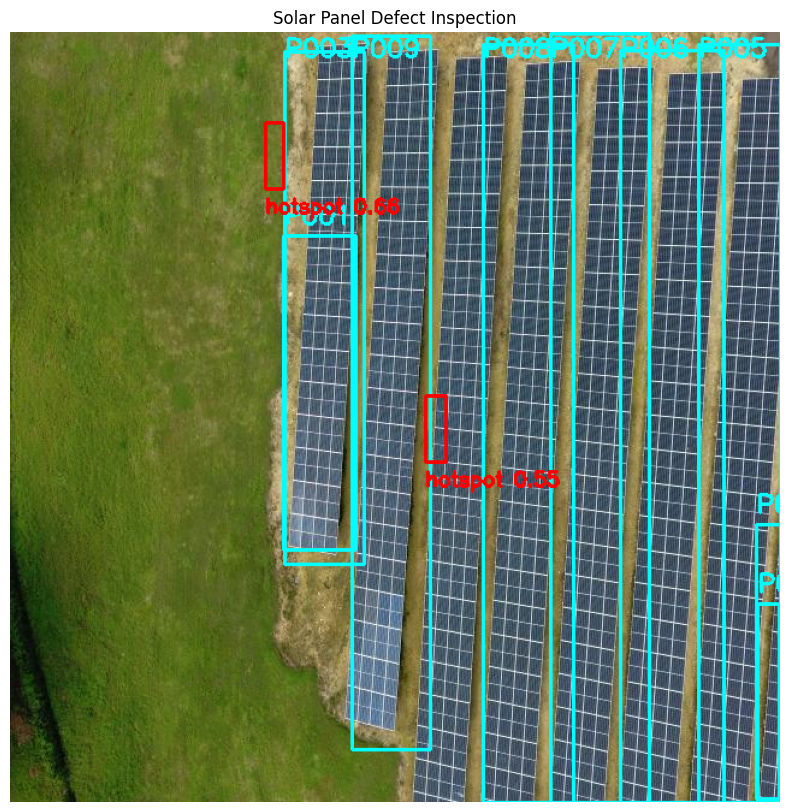

In [12]:
import matplotlib.pyplot as plt

visualization = rgb_image.copy()

# Panels: yellow
for panel in panels:
    x1, y1, x2, y2 = map(int, panel["bbox"])
    cv2.rectangle(visualization, (x1, y1), (x2, y2), (255, 255, 0), 2)
    cv2.putText(
        visualization, panel["panel_id"], (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2
    )

# RGB defects: green
for defect in rgb_defects:
    x1, y1, x2, y2 = map(int, defect["bbox"])
    label = f"{defect['class_name']} {defect['confidence']:.2f}"
    cv2.rectangle(visualization, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        visualization, label, (x1, min(y2 + 20, visualization.shape[0] - 10)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2
    )

# Thermal hotspots: red. This assumes RGB/thermal inputs are spatially aligned.
for hotspot in thermal_hotspots:
    x1, y1, x2, y2 = map(int, hotspot["bbox"])
    label = f"{hotspot['class_name']} {hotspot['confidence']:.2f}"
    cv2.rectangle(visualization, (x1, y1), (x2, y2), (0, 0, 255), 2)
    cv2.putText(
        visualization, label, (x1, min(y2 + 20, visualization.shape[0] - 10)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255), 2
    )

plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(visualization, cv2.COLOR_BGR2RGB))
plt.title("Solar Panel Defect Inspection")
plt.axis("off")
plt.show()

# Inspection Report

In [13]:
import pandas as pd

inspection_datetime = datetime.now().strftime("%d-%m-%Y %H:%M:%S")

report_records = []
for record in panel_records:
    report_records.append({
        "Date / Time": inspection_datetime,
        "Panel ID": record["Panel ID"],
        "RGB Finding": record["RGB Finding"],
        "RGB Confidence": (
            round(record["RGB Confidence"], 3)
            if record["RGB Confidence"] is not None else None
        ),
        "Thermal Finding": record["Thermal Finding"],
        "Thermal Confidence": (
            round(record["Thermal Confidence"], 3)
            if record["Thermal Confidence"] is not None else None
        ),
        "Evidence": record["Evidence"],
        "Status": record["Status"],
    })

inspection_report = pd.DataFrame(report_records)

print(f"Inspection ID: {INSPECTION_ID}")
print(f"Date / Time  : {inspection_datetime}")

display(inspection_report)

Inspection ID: INS-001
Date / Time  : 23-09-2026 17:36:50


,Date / Time,Panel ID,RGB Finding,RGB Confidence,Thermal Finding,Thermal Confidence,Evidence,Status
0,23-09-2026 17:36:50,P001,None,None,None,None,None,No Finding
1,23-09-2026 17:36:50,P002,None,None,None,None,None,No Finding
2,23-09-2026 17:36:50,P003,None,None,None,None,None,No Finding
3,23-09-2026 17:36:50,P004,None,None,None,None,None,No Finding
4,23-09-2026 17:36:50,P005,None,None,None,None,None,No Finding
5,23-09-2026 17:36:50,P006,None,None,None,None,None,No Finding
6,23-09-2026 17:36:50,P007,None,None,None,None,None,No Finding
7,23-09-2026 17:36:50,P008,None,None,None,None,None,No Finding
8,23-09-2026 17:36:50,P009,None,None,None,None,None,No Finding


### Save Inspection Report

In [14]:
REPORT_PATH = OUTPUT_DIR / "inspection_report.xlsx"

try:
    inspection_report.to_excel(REPORT_PATH, index=False)
except ModuleNotFoundError as exc:
    if "openpyxl" in str(exc):
        raise ModuleNotFoundError(
            "openpyxl is required to write the Excel report. "
            "Install it in the notebook environment with: %pip install openpyxl"
        ) from exc
    raise

print(f"Inspection report saved to: {REPORT_PATH}")

Inspection report saved to: /home/hraj/Workspace/Solor_defect_DB/Solar_Inspection/output/inspection_report.xlsx


## Inspection Report Structure

**Inspection Information**
- Inspection ID
- Date / Time

**Panel Findings**
- Panel ID
- RGB Finding + Confidence
- Thermal Finding + Confidence
- Evidence — which sensing modality detected the problem
- Status — `Requires Inspection` or `No Finding`